<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/ELM/Prediction_of_O3_based_ELM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# !Install hpelm if not already installed
# !pip install hpelm

In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from hpelm import ELM

# Load dataset
data = pd.read_csv("air_quality_o3.csv")

# Features and target
features = ["AMP_TMP","CO","NO","NO2","Nox","RH","SO2","WD","WS","PM10"]
target = "O3"

X = data[features].values
y = data[target].values

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Function to compute VAF
def vaf(y_true, y_pred):
    return 1 - np.var(y_true - y_pred)/np.var(y_true)

# =========================================================
# 1. TRAIN LINEAR REGRESSION MODEL
# =========================================================
lr = LinearRegression()
lr.fit(X_train, y_train)

# LR predictions
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# LR metrics
mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
mse_test_lr = mean_squared_error(y_test, y_test_pred_lr)

rmse_train_lr = np.sqrt(mse_train_lr)
rmse_test_lr = np.sqrt(mse_test_lr)

vaf_train_lr = vaf(y_train, y_train_pred_lr)
vaf_test_lr = vaf(y_test, y_test_pred_lr)

r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

# Print LR equation
print("\n================ LINEAR REGRESSION MODEL EQUATION ================\n")
print("O3 = b0 + b1*x1 + b2*x2 + ... + b10*x10\n")

print(f"Intercept (b0): {lr.intercept_:.6f}")
print("\nCoefficients:")
for f, c in zip(features, lr.coef_):
    print(f"{f}: {c:.6f}")


# =========================================================
# 2. TRAIN ELM MODEL (GRID SEARCH)
# =========================================================
best_neurons = None
best_vaf = -np.inf
best_model = None

for n_hidden in [100, 150, 200]:
    elm = ELM(X_train.shape[1], 1)
    elm.add_neurons(n_hidden, "tanh")

    # Ridge regression regularized training
    elm.train(X_train, y_train.reshape(-1,1), "Ridge", alpha=0.01)

    y_val_pred = elm.predict(X_train).flatten()
    current_vaf = vaf(y_train, y_val_pred)

    if current_vaf > best_vaf:
        best_vaf = current_vaf
        best_neurons = n_hidden
        best_model = elm

print(f"\nBest ELM hidden neurons: {best_neurons}, Train VAF = {best_vaf:.4f}")

# ELM Predictions
y_train_pred_elm = best_model.predict(X_train).flatten()
y_test_pred_elm = best_model.predict(X_test).flatten()

# ELM Metrics
mse_train_elm = mean_squared_error(y_train, y_train_pred_elm)
mse_test_elm = mean_squared_error(y_test, y_test_pred_elm)

rmse_train_elm = np.sqrt(mse_train_elm)
rmse_test_elm = np.sqrt(mse_test_elm)

vaf_train_elm = vaf(y_train, y_train_pred_elm)
vaf_test_elm = vaf(y_test, y_test_pred_elm)

r2_train_elm = r2_score(y_train, y_train_pred_elm)
r2_test_elm = r2_score(y_test, y_test_pred_elm)

# =========================================================
# 3. COMPARISON PERFORMANCE TABLE
# =========================================================
performance = {
    "Model": ["Linear Regression", "Linear Regression",
              "ELM", "ELM"],
    "Dataset": ["Train", "Test", "Train", "Test"],
    "MSE": [mse_train_lr, mse_test_lr, mse_train_elm, mse_test_elm],
    "RMSE": [rmse_train_lr, rmse_test_lr, rmse_train_elm, rmse_test_elm],
    "VAF": [vaf_train_lr, vaf_test_lr, vaf_train_elm, vaf_test_elm],
    "R2": [r2_train_lr, r2_test_lr, r2_train_elm, r2_test_elm]
}

performance_df = pd.DataFrame(performance)



================ LINEAR REGRESSION MODEL EQUATION ================

O3 = b0 + b1*x1 + b2*x2 + ... + b10*x10

Intercept (b0): 26.302589

Coefficients:
AMP_TMP: -3.693299
CO: -0.123135
NO: -2.172135
NO2: 9.564737
Nox: -10.928842
RH: -0.092760
SO2: -0.083480
WD: -2.139310
WS: 0.406502
PM10: 1.411097

Best ELM hidden neurons: 200, Train VAF = 0.7611


In [39]:
print("\n=================== PERFORMANCE TABLE ===================\n")
performance_df


=================== PERFORMANCE TABLE ===================



,Model,Dataset,MSE,RMSE,VAF,R2
0,Linear Regression,Train,38.261227,6.185566,0.640908,0.640908
1,Linear Regression,Test,55.165056,7.427318,0.532416,0.532411
2,ELM,Train,25.507037,5.050449,0.761086,0.760609
3,ELM,Test,55.491265,7.449246,0.533281,0.529646


In [40]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from hpelm import ELM
import matplotlib.pyplot as plt

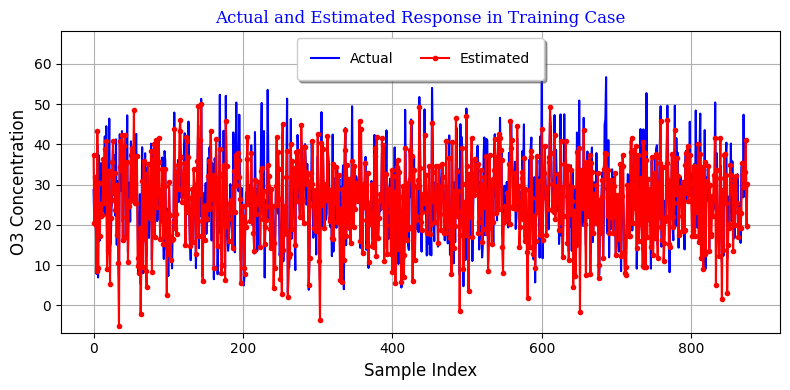

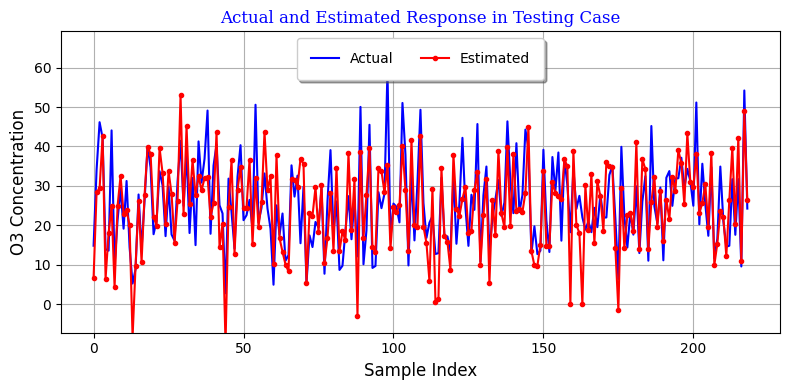

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Plot actual vs estimated responses
# -----------------------------

# Training set
fig, axs = plt.subplots(figsize=(8,4), tight_layout=True)

plt.plot(y_train, '-b', label='Actual')
plt.plot(y_train_pred, '.-r', label='Estimated')

plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('O3 Concentration', fontsize=12)

plt.title('Actual and Estimated Response in Training Case', fontname='serif', fontsize=12, color='b')
plt.ylim(np.min(y_train)-10, np.max(y_train)+10)  # adjust margin if needed
plt.legend(fancybox=True, framealpha=1, shadow=True, borderpad=1, frameon=True, loc='upper center', ncol=2)
plt.grid(True)
plt.show()

# Testing set
fig, axs = plt.subplots(figsize=(8,4), tight_layout=True)

plt.plot(y_test, '-b', label='Actual')
plt.plot(y_test_pred, '.-r', label='Estimated')

plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('O3 Concentration', fontsize=12)

plt.title('Actual and Estimated Response in Testing Case', fontname='serif', fontsize=12, color='b')
plt.ylim(np.min(y_test)-10, np.max(y_test)+10)  # adjust margin if needed
plt.legend(fancybox=True, framealpha=1, shadow=True, borderpad=1, frameon=True, loc='upper center', ncol=2)
plt.grid(True)

# Save figure (optional)
plt.savefig('Actual_Estimated_ELM.png')
plt.show()

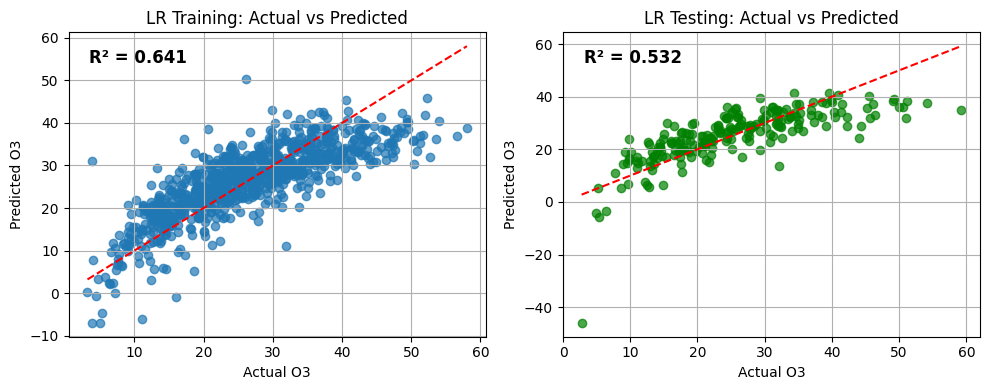

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === R2 for Linear Regression ===
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

# === FIGURE 1: Linear Regression ===
fig, axs = plt.subplots(1, 2, figsize=(10,4), tight_layout=True)

# --- Training ---
axs[0].scatter(y_train, y_train_pred_lr, alpha=0.7)
axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axs[0].set_title("LR Training: Actual vs Predicted")
axs[0].set_xlabel("Actual O3")
axs[0].set_ylabel("Predicted O3")
axs[0].text(0.05, 0.9, f"R² = {r2_train_lr:.3f}", transform=axs[0].transAxes,
            fontsize=12, fontweight='bold')
axs[0].grid(True)

# --- Testing ---
axs[1].scatter(y_test, y_test_pred_lr, alpha=0.7, color='green')
axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axs[1].set_title("LR Testing: Actual vs Predicted")
axs[1].set_xlabel("Actual O3")
axs[1].set_ylabel("Predicted O3")
axs[1].text(0.05, 0.9, f"R² = {r2_test_lr:.3f}", transform=axs[1].transAxes,
            fontsize=12, fontweight='bold')
axs[1].grid(True)

plt.savefig("LR_Correlation.png", dpi=300)
plt.show()

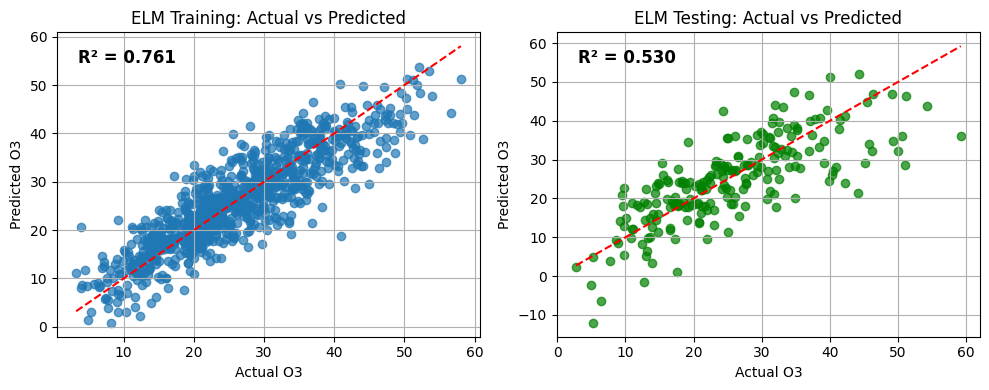

In [43]:
# === R2 for ELM ===
r2_train_elm = r2_score(y_train, y_train_pred_elm)
r2_test_elm = r2_score(y_test, y_test_pred_elm)

# === FIGURE 2: ELM ===
fig, axs = plt.subplots(1, 2, figsize=(10,4), tight_layout=True)

# --- Training ---
axs[0].scatter(y_train, y_train_pred_elm, alpha=0.7)
axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axs[0].set_title("ELM Training: Actual vs Predicted")
axs[0].set_xlabel("Actual O3")
axs[0].set_ylabel("Predicted O3")
axs[0].text(0.05, 0.9, f"R² = {r2_train_elm:.3f}", transform=axs[0].transAxes,
            fontsize=12, fontweight='bold')
axs[0].grid(True)

# --- Testing ---
axs[1].scatter(y_test, y_test_pred_elm, alpha=0.7, color='green')
axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axs[1].set_title("ELM Testing: Actual vs Predicted")
axs[1].set_xlabel("Actual O3")
axs[1].set_ylabel("Predicted O3")
axs[1].text(0.05, 0.9, f"R² = {r2_test_elm:.3f}", transform=axs[1].transAxes,
            fontsize=12, fontweight='bold')
axs[1].grid(True)

plt.savefig("ELM_Correlation.png", dpi=300)
plt.show()


In [44]:
data.describe()

,AMP_TMP,CO,NO,NO2,Nox,RH,SO2,WD,WS,PM10,O3
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,22.828889,0.387773,4.538562,11.245281,15.786744,80.052298,2.623121,190.417708,1.701910,37.979963,26.297766
std,5.265200,0.125974,2.678366,3.526464,5.244952,8.446745,1.583075,44.479594,0.675993,21.226532,10.448088
min,9.225000,0.037500,0.278750,0.824167,1.103333,46.290000,0.262500,52.460000,0.779583,3.833333,2.762500
25%,18.771458,0.300000,2.662708,8.713333,12.020417,74.204167,1.802083,159.243750,1.310000,25.311667,18.920417
50%,23.010417,0.370000,3.925833,10.897500,15.340000,80.305417,2.312500,185.715833,1.562500,34.833333,25.550000
75%,27.685000,0.466875,5.904167,13.685625,19.098333,86.270000,3.041667,220.422917,1.904167,46.479167,33.291667
max,32.250000,0.940000,29.379583,27.203333,43.938333,97.083333,22.750000,302.298333,8.609583,377.500000,59.208333
